# Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.tsa.stattools import adfuller
import warnings
import os

warnings.filterwarnings("ignore")

# Load Modelling Dataset

In [2]:
df = pd.read_csv(r"..\..\Data\Main\modelling_dataset.csv")
df['date'] = pd.to_datetime(df['date'])
print(f"Shape: {df.shape}")
print(f"Tickers: {df['ticker'].nunique()}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")

os.makedirs(r"..\..\EDA", exist_ok=True)
print("EDA folder created")

Shape: (589886, 15)
Tickers: 523
Date range: 2020-01-02 00:00:00 to 2025-12-31 00:00:00
EDA folder created


The modelling dataset contains 589,886 stock-day observations across 523 S&P 500 constituents from January 2020 to December 2025, covering a six-year period that includes the COVID-19 crash, the 2022 rate-hiking cycle, and the 2025 tariff uncertainty period.

# Descriptive Statistics

In [3]:
stats_vars = ['sentiment', 'log_return', 'volatility_20d', 'next_day_return']
desc = df[stats_vars].describe(percentiles=[0.25, 0.5, 0.75]).T
desc = desc[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']]
desc = desc.round(6)
print(desc.to_string())

                    count      mean       std       min       25%       50%       75%       max
sentiment        589886.0 -0.008624  0.324341 -1.000000 -0.084100  0.000000  0.064200  1.000000
log_return       589363.0  0.000360  0.025145 -0.963050 -0.010222  0.000718  0.011478  0.396572
volatility_20d   579426.0  0.021540  0.013159  0.001346  0.013638  0.018264  0.025045  0.287376
next_day_return  589363.0  0.000360  0.025145 -0.963050 -0.010222  0.000718  0.011478  0.396572


### Interpretation

- **Sentiment** has a mean of -0.009, indicating a very slight negative tilt in Bloomberg news coverage across the study period. The median is exactly zero, reflecting the large proportion of days with no scored news. The full -1 to +1 range confirms the data contains both strongly negative and strongly positive sentiment days.
- **Log returns** have a mean near zero (0.0004), which is typical for daily stock returns. The standard deviation of 0.025 (2.5%) is consistent with normal equity market volatility. The minimum of -0.963 represents an extreme single-day loss, likely from an acquisition or corporate event.
- **Volatility (20-day rolling)** has a mean of 0.022 but a maximum of 0.287 — over 13 times the mean — reflecting the extreme market conditions during the COVID-19 crash in early 2020.
- **Next-day return** has identical aggregate statistics to log_return, which is expected since it is the same series shifted by one trading day.

## Class Balance and Coverage Statistics

In [4]:
print("=== Target Variable ===")
print(df['target'].value_counts(normalize=True).round(4))

non_zero = (df['sentiment'] != 0).sum()
total = len(df)
print(f"\n=== Sentiment Coverage ===")
print(f"Non-zero sentiment: {non_zero:,} ({non_zero/total*100:.1f}%)")
print(f"Zero sentiment: {total - non_zero:,} ({(total-non_zero)/total*100:.1f}%)")

obs_per_ticker = df.groupby('ticker').size()
print(f"\n=== Observations per Ticker ===")
print(f"Mean: {obs_per_ticker.mean():.0f}")
print(f"Min: {obs_per_ticker.min()}")
print(f"Max: {obs_per_ticker.max()}")

=== Target Variable ===
target
1    0.5173
0    0.4827
Name: proportion, dtype: float64

=== Sentiment Coverage ===
Non-zero sentiment: 445,229 (75.5%)
Zero sentiment: 144,657 (24.5%)

=== Observations per Ticker ===
Mean: 1128
Min: 128
Max: 1507


### Interpretation

The target variable is near-balanced at 51.7% positive (up) and 48.3% negative (down). This eliminates the need for resampling techniques such as SMOTE and establishes a naive baseline: a model that always predicts "up" would achieve 51.7% accuracy. Any useful model must exceed this baseline.

75.5% of observations have non-zero sentiment scores, indicating strong Bloomberg news coverage across the sample. The 24.5% zero-sentiment days represent trading days where Bloomberg did not score any news for that ticker. This motivates a robustness check comparing model performance with and without zero-sentiment observations.

The average ticker has 1,128 observations. The minimum of 128 corresponds to companies with short index membership, while the maximum of 1,507 represents companies present across the full six-year study period.

## Correlation Matrix

In [5]:
corr_vars = ['sentiment', 'log_return', 'volatility_20d', 'next_day_return', 'sent_x_vol', 'market_vol']
corr_matrix = df[corr_vars].corr().round(4)
print(corr_matrix.to_string())

                 sentiment  log_return  volatility_20d  next_day_return  sent_x_vol  market_vol
sentiment           1.0000      0.0563         -0.0038          -0.0046      0.8663      0.0153
log_return          0.0563      1.0000          0.0061          -0.0363      0.0684      0.0202
volatility_20d     -0.0038      0.0061          1.0000           0.0231     -0.0440      0.6504
next_day_return    -0.0046     -0.0363          0.0231           1.0000     -0.0000      0.0297
sent_x_vol          0.8663      0.0684         -0.0440          -0.0000      1.0000      0.0083
market_vol          0.0153      0.0202          0.6504           0.0297      0.0083      1.0000


### Interpretation

- **Sentiment → next_day_return (-0.005):** Near-zero linear correlation, suggesting that any predictive relationship is non-linear or conditional — consistent with the moderation hypothesis being tested.
- **Sentiment → volatility_20d (-0.004):** Near-zero correlation confirms that sentiment and volatility measure genuinely different market dimensions. This independence is important because it means the interaction term in the model captures a real combined effect rather than redundancy between correlated inputs.
- **Sentiment → sent_x_vol (0.87):** High correlation is expected and not problematic — the interaction term is derived from sentiment, so mathematical correlation is inherent. The model handles this because the interaction term's purpose is to capture the combined effect.
- **Volatility_20d → market_vol (0.65):** Moderate positive correlation reflects the intuitive relationship that individual stock volatility rises when the broader market is volatile. The correlation is not high enough to indicate redundancy, supporting the use of stock-level volatility in the main model and market-level volatility for the split-sample analysis.
- **Log_return → next_day_return (-0.036):** Slight negative correlation indicates mild mean reversion — stocks that rise today are marginally more likely to fall tomorrow, and vice versa.

## Market-Wide Volatility Over Time

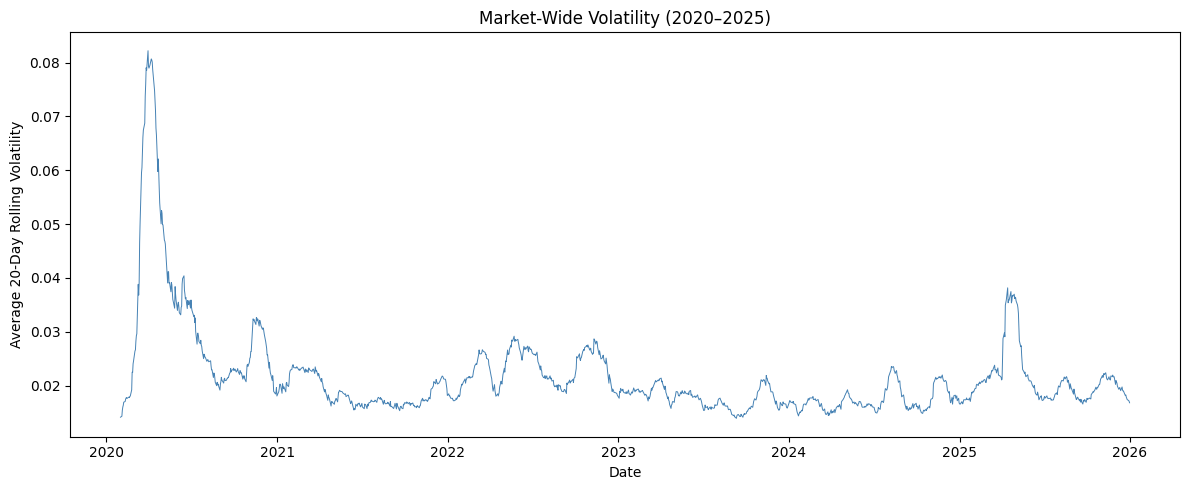

In [6]:
market_vol = df.dropna(subset=['market_vol']).groupby('date')['market_vol'].first()

plt.figure(figsize=(12, 5))
plt.plot(market_vol.index, market_vol.values, linewidth=0.7, color='steelblue')
plt.title('Market-Wide Volatility (2020–2025)')
plt.xlabel('Date')
plt.ylabel('Average 20-Day Rolling Volatility')
plt.tight_layout()
plt.savefig(r"..\..\EDA\volatility_over_time.png", dpi=150)
plt.show()

### Interpretation

The plot reveals substantial variation in market-wide volatility across the study period, visually motivating the core research question. The COVID-19 crash in March 2020 produced a peak of approximately 0.082, roughly four times the typical level. Volatility remained elevated through late 2020 before normalising. The early 2022 period shows a notable increase corresponding to Federal Reserve rate hikes and the Russia-Ukraine conflict. A sharp spike appears in early-mid 2025, coinciding with US tariff policy uncertainty. Calm periods in 2023–2024 settle around 0.017–0.020.

This dramatic variation in volatility across the study period provides the ideal setting to test whether sentiment's predictive power differs between volatile and calm market regimes.

## Sentiment Distribution

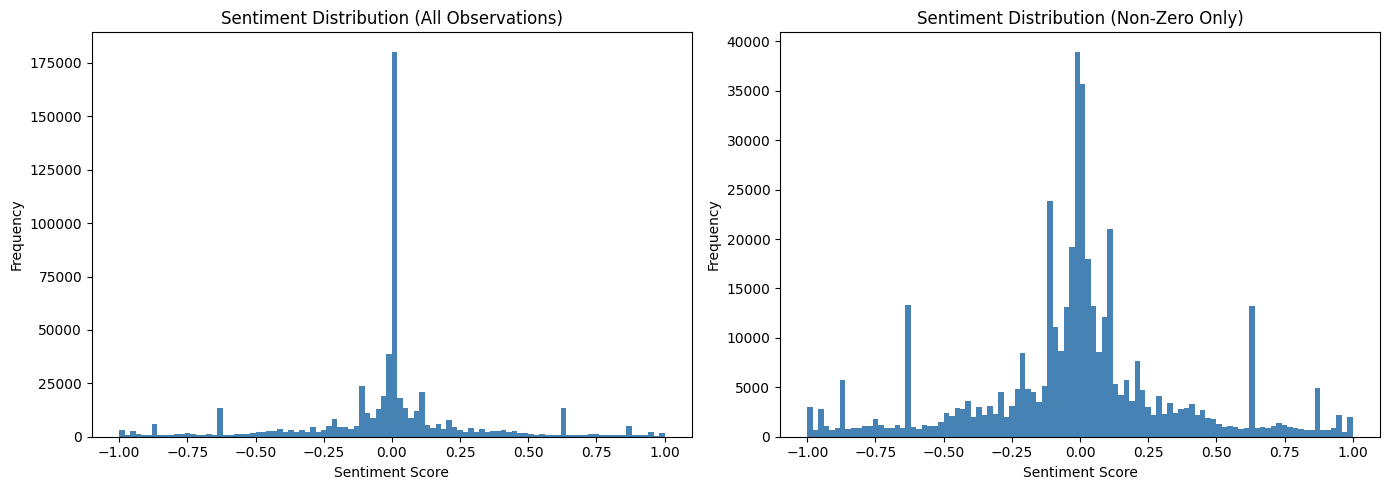

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['sentiment'], bins=100, color='steelblue', edgecolor='none')
axes[0].set_title('Sentiment Distribution (All Observations)')
axes[0].set_xlabel('Sentiment Score')
axes[0].set_ylabel('Frequency')

non_zero_sent = df.loc[df['sentiment'] != 0, 'sentiment']
axes[1].hist(non_zero_sent, bins=100, color='steelblue', edgecolor='none')
axes[1].set_title('Sentiment Distribution (Non-Zero Only)')
axes[1].set_xlabel('Sentiment Score')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig(r"..\..\EDA\sentiment_distribution.png", dpi=150)
plt.show()

### Interpretation

The left panel confirms the dominant zero-sentiment spike, representing 24.5% of all observations — days where Bloomberg did not score any news for that ticker.

The right panel (non-zero only) reveals the underlying signal distribution. Sentiment is roughly centred just below zero, consistent with the slight negative mean. Most non-zero values cluster between -0.3 and +0.3, indicating that Bloomberg sentiment tends to be mild rather than extreme. Notable spikes appear at -1.0 and +1.0, representing days of unanimously negative or positive news coverage. The "spiky" texture is normal for this data — Bloomberg averages discrete news scores, so certain values recur frequently.

The key implication is that while genuine variation exists across the full range, most of the sentiment signal lives in a narrow band near zero. This makes the interaction with volatility particularly relevant — during volatile periods, greater sentiment dispersion may provide a stronger signal for prediction.

## Sentiment Dispersion by Volatility Quintile

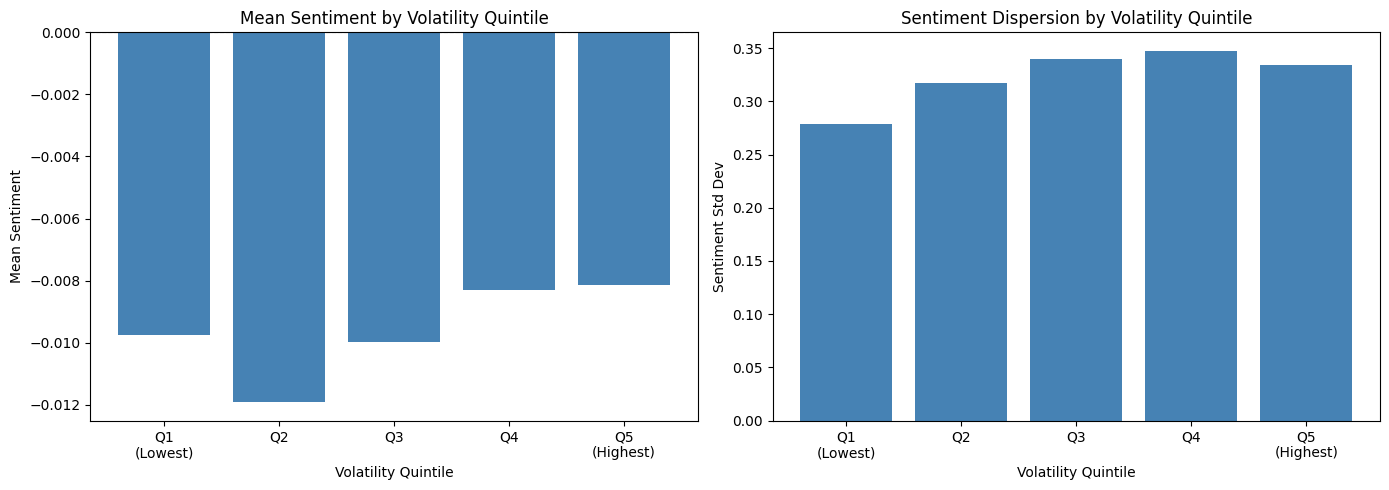

In [8]:
plot_df = df.dropna(subset=['volatility_20d', 'sentiment']).copy()
plot_df['vol_quintile'] = pd.qcut(plot_df['volatility_20d'], 5, labels=['Q1\n(Lowest)', 'Q2', 'Q3', 'Q4', 'Q5\n(Highest)'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

vol_sent = plot_df.groupby('vol_quintile')['sentiment'].mean()
axes[0].bar(vol_sent.index, vol_sent.values, color='steelblue')
axes[0].set_title('Mean Sentiment by Volatility Quintile')
axes[0].set_xlabel('Volatility Quintile')
axes[0].set_ylabel('Mean Sentiment')
axes[0].axhline(y=0, color='grey', linestyle='--', linewidth=0.8)

vol_sent_std = plot_df.groupby('vol_quintile')['sentiment'].std()
axes[1].bar(vol_sent_std.index, vol_sent_std.values, color='steelblue')
axes[1].set_title('Sentiment Dispersion by Volatility Quintile')
axes[1].set_xlabel('Volatility Quintile')
axes[1].set_ylabel('Sentiment Std Dev')

plt.tight_layout()
plt.savefig(r"..\..\EDA\sentiment_by_volatility.png", dpi=150)
plt.show()

### Interpretation

**Left panel (Mean Sentiment):** There is no consistent relationship between volatility level and sentiment direction. All quintiles show mildly negative mean sentiment, and the most volatile quintile (Q5) is not systematically more negative than calm periods. This indicates that high volatility does not simply equate to negative news — the two variables capture different market dimensions.

**Right panel (Sentiment Dispersion):** Sentiment standard deviation increases from approximately 0.28 in Q1 (calmest markets) to 0.34 in Q3–Q5 (most volatile). This represents a roughly 21% increase in sentiment dispersion. During volatile periods, Bloomberg sentiment scores are more extreme in both directions — more strongly positive and more strongly negative — rather than uniformly negative.

Higher volatility is associated with greater dispersion of sentiment scores rather than a consistent shift in sentiment direction. This suggests that volatile markets amplify the range of news signals available to investors, providing the conditions under which sentiment may have greater predictive power.

## Average Daily Sentiment Over Time

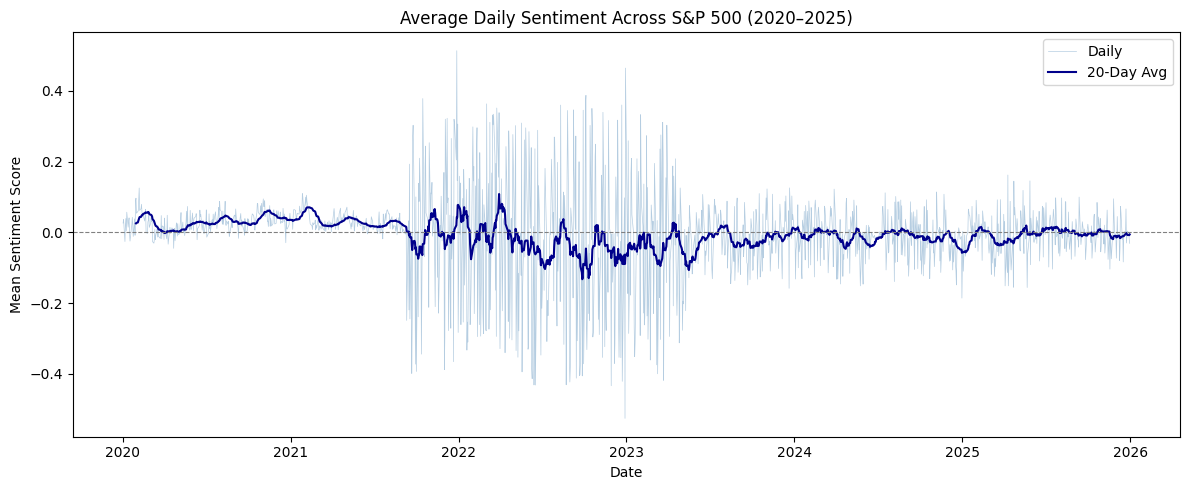

In [9]:
daily_sent = df.groupby('date')['sentiment'].mean()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(daily_sent.index, daily_sent.values, linewidth=0.5, color='steelblue', alpha=0.4, label='Daily')

rolling_sent = daily_sent.rolling(20).mean()
ax.plot(rolling_sent.index, rolling_sent.values, linewidth=1.5, color='darkblue', label='20-Day Avg')

ax.set_title('Average Daily Sentiment Across S&P 500 (2020–2025)')
ax.set_xlabel('Date')
ax.set_ylabel('Mean Sentiment Score')
ax.axhline(y=0, color='grey', linestyle='--', linewidth=0.8)
ax.legend()
plt.tight_layout()
plt.savefig(r"..\..\EDA\sentiment_over_time.png", dpi=150)
plt.show()

### Interpretation

Sentiment was mildly positive and stable through 2020 to mid-2021. Daily variation (light blue) was narrow during this period. From mid-2021 onward, daily variation increases substantially, and the 20-day average turns notably negative through most of 2022 into early 2023 — coinciding with Federal Reserve rate hikes and persistent inflation fears. This represents the longest sustained period of negative sentiment in the study window. Sentiment gradually normalises through 2024–2025.

The sharp increase in daily variability from mid-2021 is linked to the Bloomberg sentiment coverage expansion identified in the following chart.

## Bloomberg Sentiment Coverage Over Time

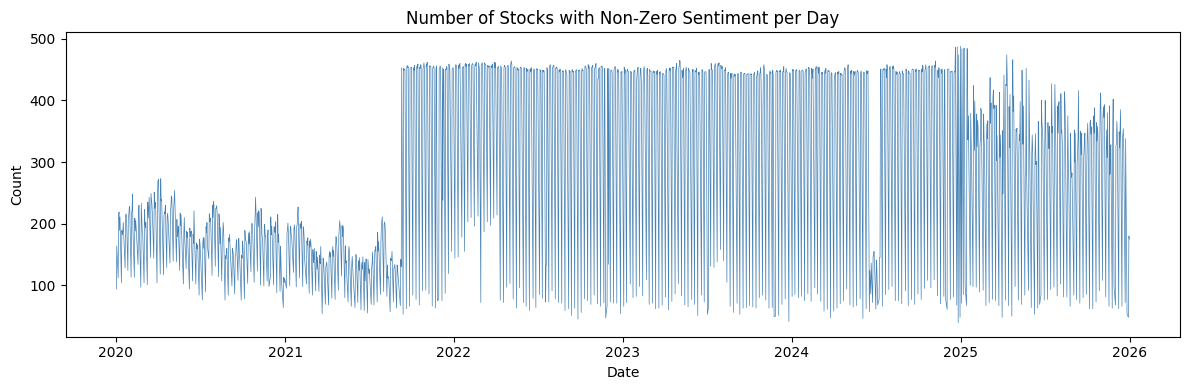

In [10]:
daily_counts = df[df['sentiment'] != 0].groupby('date')['ticker'].count()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(daily_counts.index, daily_counts.values, linewidth=0.5, color='steelblue')
ax.set_title('Number of Stocks with Non-Zero Sentiment per Day')
ax.set_xlabel('Date')
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig(r"..\..\EDA\sentiment_coverage_over_time.png", dpi=150)
plt.show()

### Interpretation

Bloomberg sentiment coverage approximately doubled around mid-2021, from roughly 150–200 stocks scored daily to approximately 400–450. This structural change in data provider coverage explains the increased variability in the sentiment time series from mid-2021 onward — more stocks being scored naturally produces a wider range of daily sentiment averages.

This coverage shift is noted as a methodological consideration. Since the analysis operates at the individual stock-day level, this change affects sample composition but not the validity of individual observations. Each stock-day row contains that specific stock's sentiment score regardless of how many other stocks were scored on the same day. A pre/post coverage split is noted as potential future work.

## Distribution of Daily Log Returns

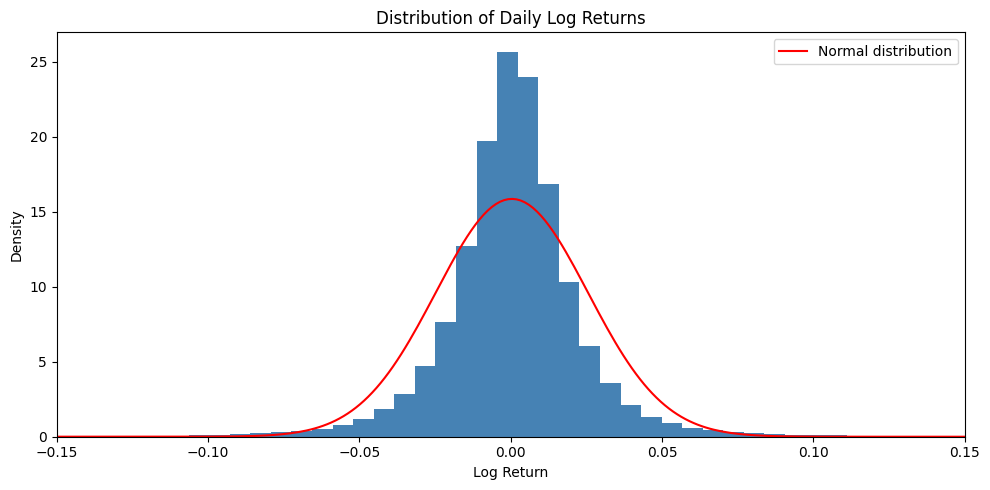

In [11]:
returns = df['log_return'].dropna()

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(returns, bins=200, color='steelblue', edgecolor='none', density=True)

x = np.linspace(returns.min(), returns.max(), 1000)
ax.plot(x, stats.norm.pdf(x, returns.mean(), returns.std()), 'r-', linewidth=1.5, label='Normal distribution')

ax.set_title('Distribution of Daily Log Returns')
ax.set_xlabel('Log Return')
ax.set_ylabel('Density')
ax.set_xlim(-0.15, 0.15)
ax.legend()
plt.tight_layout()
plt.savefig(r"..\..\EDA\return_distribution.png", dpi=150)
plt.show()

### Interpretation

The distribution of daily log returns exhibits leptokurtosis — a taller, narrower peak than the normal distribution (blue exceeds red at centre) with fatter tails (blue extends further at extremes). This is one of the most established empirical facts in finance: extreme market days occur more frequently than a normal distribution predicts.

This non-normality has two implications for the study. First, it justifies the use of binary classification (predicting direction) rather than regression (predicting magnitude), as fat-tailed returns make magnitude prediction unreliable. Second, the extreme return days concentrated in high-volatility periods are precisely the observations where the sentiment-volatility interaction is expected to be most informative.

## Sentiment-Return Relationship by Decile (Overall)

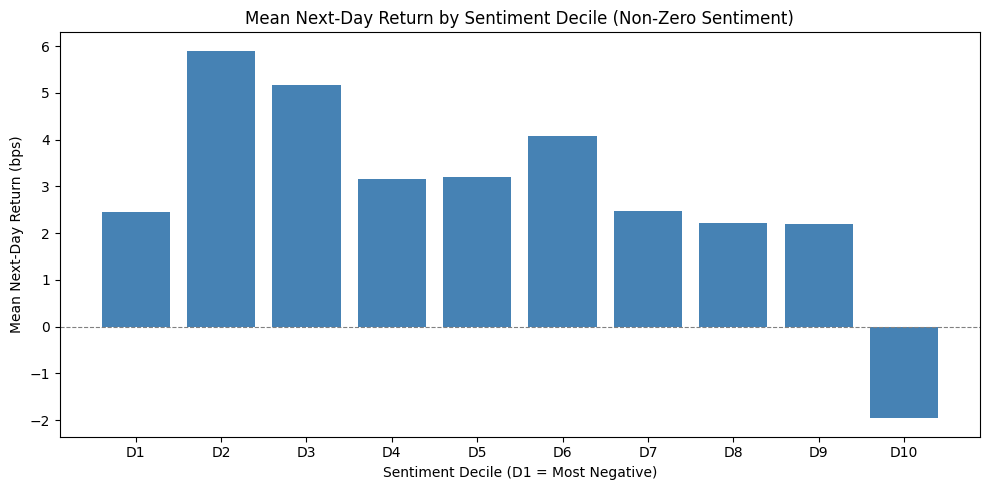

In [12]:
plot_df2 = df.dropna(subset=['next_day_return', 'sentiment']).copy()
plot_df2 = plot_df2[plot_df2['sentiment'] != 0]
plot_df2['sent_decile'] = pd.qcut(plot_df2['sentiment'], 10, labels=[f'D{i}' for i in range(1, 11)], duplicates='drop')

fig, ax = plt.subplots(figsize=(10, 5))
decile_returns = plot_df2.groupby('sent_decile')['next_day_return'].mean()
ax.bar(decile_returns.index, decile_returns.values * 10000, color='steelblue')
ax.set_title('Mean Next-Day Return by Sentiment Decile (Non-Zero Sentiment)')
ax.set_xlabel('Sentiment Decile (D1 = Most Negative)')
ax.set_ylabel('Mean Next-Day Return (bps)')
ax.axhline(y=0, color='grey', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.savefig(r"..\..\EDA\sentiment_return_decile.png", dpi=150)
plt.show()

### Interpretation

The overall relationship between sentiment and next-day returns does not follow a simple positive pattern. Instead, D2–D3 (moderately negative sentiment) produce the highest next-day returns at approximately 5–6 basis points, while D10 (most positive sentiment) produces slightly negative next-day returns.

This pattern is consistent with the well-documented mean reversion or overreaction effect in finance: stocks with negative news tend to be oversold, leading to a partial recovery the following day, while stocks with very positive news tend to be overbought, giving back some gains. The relationship between sentiment and returns exists, but it is non-linear and more nuanced than "positive sentiment predicts positive returns."

Critically, this is the aggregate pattern across all market conditions. The following split-sample analysis examines whether this pattern differs between volatile and calm market regimes.

## Sentiment-Return Relationship Split by Volatile vs Calm Markets

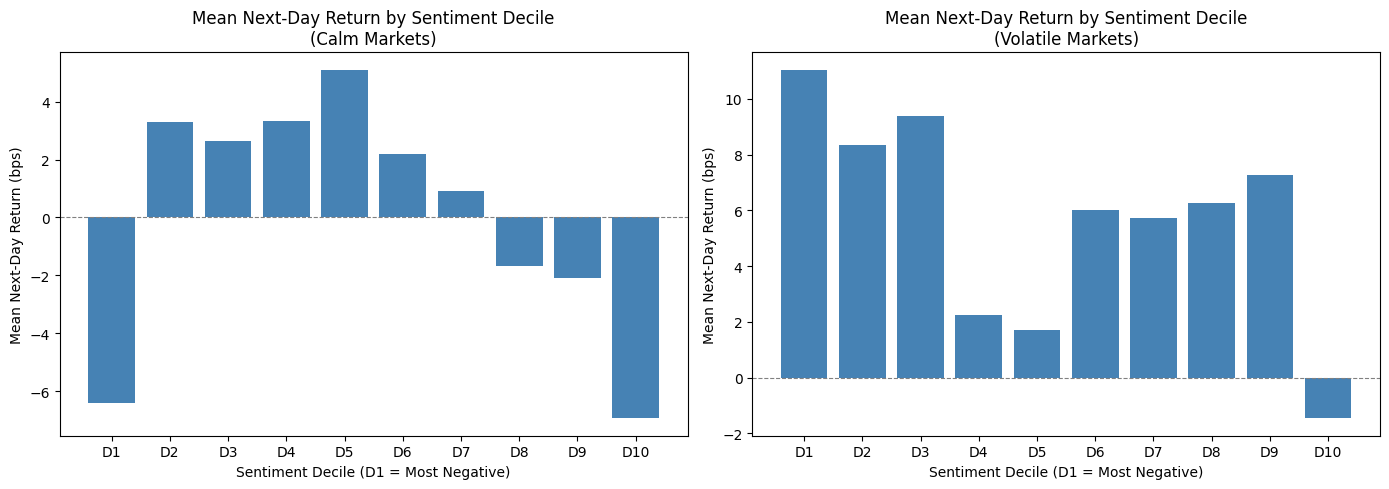

In [13]:
plot_df3 = df.dropna(subset=['next_day_return', 'sentiment', 'volatile_market']).copy()
plot_df3 = plot_df3[plot_df3['sentiment'] != 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, (regime, label) in enumerate([(0, 'Calm Markets'), (1, 'Volatile Markets')]):
    sub = plot_df3[plot_df3['volatile_market'] == regime].copy()
    sub['sent_decile'] = pd.qcut(sub['sentiment'], 10, labels=[f'D{j}' for j in range(1, 11)], duplicates='drop')
    decile_ret = sub.groupby('sent_decile')['next_day_return'].mean()
    axes[i].bar(decile_ret.index, decile_ret.values * 10000, color='steelblue')
    axes[i].set_title(f'Mean Next-Day Return by Sentiment Decile\n({label})')
    axes[i].set_xlabel('Sentiment Decile (D1 = Most Negative)')
    axes[i].set_ylabel('Mean Next-Day Return (bps)')
    axes[i].axhline(y=0, color='grey', linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.savefig(r"..\..\EDA\sentiment_return_by_regime.png", dpi=150)
plt.show()

### Interpretation

The patterns differ substantially between market regimes, providing direct visual evidence for the moderation hypothesis.

**Calm markets (left):** The sentiment-return relationship is noisy and shows no clear trend. Both D1 (most negative) and D10 (most positive) produce negative returns, while moderate sentiment (D2–D5) produces positive returns. The pattern resembles an inverted U-shape, suggesting that during calm periods, sentiment provides an unreliable and inconsistent signal for next-day returns.

**Volatile markets (right):** A much clearer downward pattern emerges. D1 (most negative sentiment) produces the highest next-day returns at approximately +11 basis points, declining as sentiment becomes more positive, with D10 near zero or slightly negative. The mean reversion effect is substantially amplified — negative news overshoots during volatile periods, leading to larger bounce-backs.

Two key observations support the moderation hypothesis:
1. **Magnitudes are roughly double.** Volatile-period returns range from +11 to -2 bps, compared to -6 to +5 bps in calm periods.
2. **The pattern is more consistent.** Calm markets show a noisy, non-monotonic relationship, while volatile markets show a clearer directional pattern that a predictive model could potentially exploit.

This visual evidence will be formally tested through the logistic regression interaction term and the split-sample model comparison.

## Year-by-Year Summary

In [14]:
df['year'] = df['date'].dt.year

yearly = df.groupby('year').agg(
    observations=('sentiment', 'count'),
    tickers=('ticker', 'nunique'),
    mean_sentiment=('sentiment', 'mean'),
    mean_volatility=('volatility_20d', 'mean'),
    mean_return=('log_return', 'mean'),
    pct_up=('target', 'mean'),
    pct_nonzero_sent=('sentiment', lambda x: (x != 0).mean())
).round(4)

yearly['pct_up'] = (yearly['pct_up'] * 100).round(1)
yearly['pct_nonzero_sent'] = (yearly['pct_nonzero_sent'] * 100).round(1)

print(yearly.to_string())

      observations  tickers  mean_sentiment  mean_volatility  mean_return  pct_up  pct_nonzero_sent
year                                                                                               
2020         83756      456          0.0293           0.0344       0.0004    51.6              53.5
2021         90836      472          0.0193           0.0187       0.0012    53.6              58.9
2022        105783      486         -0.0399           0.0231      -0.0007    49.1              88.8
2023        104862      492         -0.0273           0.0177       0.0005    51.8              87.4
2024        105423      499         -0.0164           0.0174       0.0004    52.4              83.9
2025         99226      492         -0.0048           0.0213       0.0004    52.1              73.4


### Interpretation

- **2020** was the most volatile year (mean volatility 0.034) yet had the most positive sentiment (0.029) — the recovery rally from April onward generated optimistic coverage outweighing the March crash.
- **2022** had the most negative sentiment (-0.040) and was the only year where stocks fell more often than they rose (49.1% up days), reflecting Federal Reserve rate hikes and inflation concerns.
- **Sentiment coverage** jumped from 53.5% in 2020 to 88.8% in 2022, confirming the mid-2021 Bloomberg coverage expansion.
- **2023–2025** show gradual normalisation toward neutral sentiment and typical volatility levels.
- **Ticker count** increases from 456 in 2020 to 499 in 2024, reflecting S&P 500 composition changes captured by the quarterly membership panel.

## Monthly Observation Count

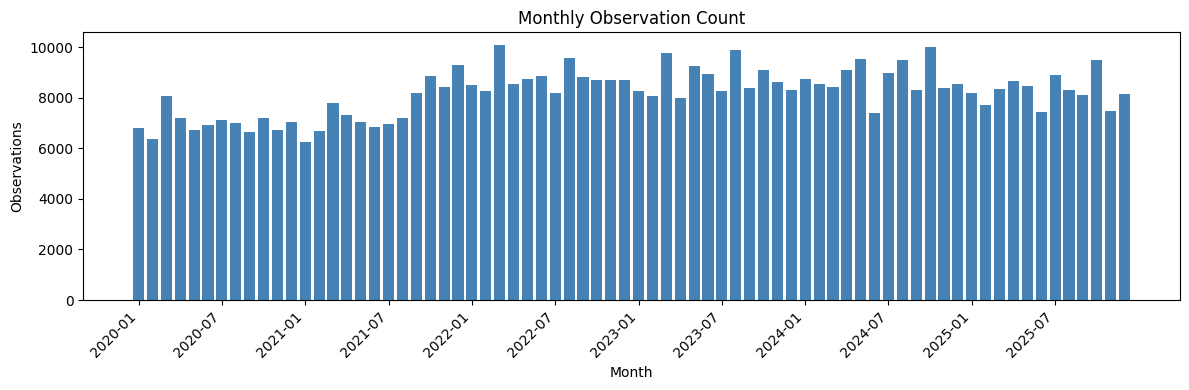

In [15]:
monthly_obs = df.groupby(df['date'].dt.to_period('M')).size()

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(range(len(monthly_obs)), monthly_obs.values, color='steelblue', edgecolor='none')
ax.set_title('Monthly Observation Count')
ax.set_xlabel('Month')
ax.set_ylabel('Observations')

tick_positions = range(0, len(monthly_obs), 6)
tick_labels = [str(monthly_obs.index[i]) for i in tick_positions]
ax.set_xticks(list(tick_positions))
ax.set_xticklabels(tick_labels, rotation=45, ha='right')

plt.tight_layout()
plt.savefig(r"..\..\EDA\monthly_observations.png", dpi=150)
plt.show()

### Interpretation

Observations are distributed continuously across the full study period with no gaps or anomalously thin months. The step-up from approximately 6,500–7,000 per month in 2020–2021 to 8,000–10,000 from 2022 onward mirrors the Bloomberg sentiment coverage expansion. Monthly variation within each period reflects different numbers of trading days per month (February is shorter, some months have public holidays).

This continuous coverage ensures that walk-forward validation will not encounter any data gaps during training or testing windows.

## Stationarity Tests (ADF)

In [16]:
daily_means = df.groupby('date').agg(
    sentiment=('sentiment', 'mean'),
    log_return=('log_return', 'mean'),
    volatility_20d=('volatility_20d', 'mean')
).dropna()

results = []
for col in ['sentiment', 'log_return', 'volatility_20d']:
    adf_stat, p_value, usedlag, nobs, crit_values, icbest = adfuller(daily_means[col], maxlag=20)
    results.append({
        'Variable': col,
        'ADF Statistic': round(adf_stat, 4),
        'p-value': round(p_value, 6),
        '1% Critical': round(crit_values['1%'], 4),
        '5% Critical': round(crit_values['5%'], 4),
        'Stationary?': 'Yes' if p_value < 0.05 else 'No'
    })

adf_df = pd.DataFrame(results)
print(adf_df.to_string(index=False))

      Variable  ADF Statistic  p-value  1% Critical  5% Critical Stationary?
     sentiment        -6.2205 0.000000      -3.4348      -2.8635         Yes
    log_return       -11.2789 0.000000      -3.4348      -2.8635         Yes
volatility_20d        -3.8203 0.002706      -3.4348      -2.8635         Yes


### Interpretation

Augmented Dickey-Fuller tests confirm that all three key variables — sentiment, log returns, and volatility — are stationary at the 1% significance level. This means none of the variables exhibit trends or unit roots that would invalidate their use in predictive modelling. No differencing or detrending is required.

## Sector Breakdown

In [17]:
import yfinance as yf

tickers = df['ticker'].unique()
print(f"Fetching sectors for {len(tickers)} tickers...")

sector_map = {}
failed = []
for i, t in enumerate(tickers):
    try:
        info = yf.Ticker(t).info
        sector_map[t] = info.get('sector', 'Unknown')
    except:
        failed.append(t)
        sector_map[t] = 'Unknown'
    if (i + 1) % 50 == 0:
        print(f"  Done {i+1}/{len(tickers)}")

print(f"\nCompleted. Failed: {len(failed)}")

sector_df = pd.DataFrame(list(sector_map.items()), columns=['ticker', 'sector'])
sector_df.to_csv(r"..\..\Data\Main\ticker_sectors.csv", index=False)

sector_summary = df.merge(sector_df, on='ticker', how='left').groupby('sector').agg(
    tickers=('ticker', 'nunique'),
    observations=('sentiment', 'count'),
    mean_sentiment=('sentiment', 'mean'),
    mean_volatility=('volatility_20d', 'mean'),
    pct_up=('target', 'mean')
).round(4)

sector_summary['pct_up'] = (sector_summary['pct_up'] * 100).round(1)
sector_summary = sector_summary.sort_values('tickers', ascending=False)

print(sector_summary.to_string())

Fetching sectors for 523 tickers...
  Done 50/523
  Done 100/523
  Done 150/523
  Done 200/523
  Done 250/523
  Done 300/523
  Done 350/523
  Done 400/523
  Done 450/523
  Done 500/523

Completed. Failed: 0
                        tickers  observations  mean_sentiment  mean_volatility  pct_up
sector                                                                                
Technology                   82         86672          0.0006           0.0243    52.3
Industrials                  74         80359         -0.0050           0.0210    51.9
Financial Services           71         81963         -0.0059           0.0204    52.4
Consumer Cyclical            67         73561         -0.0052           0.0249    51.0
Healthcare                   63         72940         -0.0150           0.0205    51.3
Consumer Defensive           37         45403         -0.0091           0.0167    51.4
Real Estate                  32         33368         -0.0201           0.0205    51.3
Utilities 

## Interpretation

The sample spans all 11 GICS sectors with no single sector dominating. Technology is the largest at 82 tickers (16%), consistent with its weight in the S&P 500. Sentiment varies by sector: Technology is the only sector with positive mean sentiment (0.001), while Communication Services (-0.028) and Utilities (-0.022) are the most negative. Volatility also varies: Energy (0.026) and Consumer Cyclical (0.025) are the most volatile, while Consumer Defensive (0.017) and Utilities (0.017) are the calmest. Class balance is consistent across all sectors (50.9%–52.4%), confirming that the target variable is not driven by sector-specific effects.

This sector diversity supports the generalisability of findings across the S&P 500, and reduces the risk that results are driven by one particular sector's behaviour.